# Past rates EDA, ETL and Visualization
#### Dataset: `../data/past_rates.parquet`

In [27]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
# Setting up libraries configurations

# Pandas:
pd.set_option('display.max_rows', 61)
pd.set_option('display.max_row', 61)
pd.set_option('display.date_yearfirst', True)
pd.option_context('display.max_rows', None)

# Matplotlib defaults


In [29]:
RATES_DATASET = "../data/past_rates.parquet"
EXACT_COLUMNS = ['listing_id', 'date', 'vacant_days', 'reserved_days', 'occupancy', 'revenue', 'rate_avg', 
                'booked_rate_avg', 'booking_lead_time_avg', 'length_of_stay_avg', 'min_nights_avg',
                'native_booked_rate_avg', 'native_rate_avg', 'native_revenue', 'country', 'state', 'city'
]
TARGET_COLS = ['']
     


In [30]:
# df_rates = pd.read_parquet(RATES_DATASET)
# df_rates.head()
df_pqt = pd.read_parquet(RATES_DATASET, engine='pyarrow')
df_pqt.head()

,listing_id,date,vacant_days,reserved_days,occupancy,revenue,rate_avg,booked_rate_avg,booking_lead_time_avg,length_of_stay_avg,min_nights_avg,native_booked_rate_avg,native_rate_avg,native_revenue,country,state,city
0,715948003276412382,2025-02-01,7,21,0.750,860.0,40.6,41.0,7.0,4.0,2.0,1469.0,1455.0,30821.0,Turkey,Istanbul,Kadıköy
1,715948003276412382,2025-03-01,4,27,0.871,1100.0,40.8,40.7,34.0,4.0,3.0,1482.0,1485.0,40044.0,Turkey,Istanbul,Kadıköy
2,715948003276412382,2025-04-01,8,22,0.733,886.0,40.5,40.3,15.0,4.0,3.0,1530.0,1538.0,33637.0,Turkey,Istanbul,Kadıköy
3,715948003276412382,2025-05-01,3,28,0.903,1117.0,40.6,39.9,23.0,10.0,3.0,1539.0,1566.0,43088.0,Turkey,Istanbul,Kadıköy
4,715948003276412382,2025-06-01,23,7,0.233,320.0,51.0,45.7,13.0,4.0,3.0,1793.0,2001.0,12557.0,Turkey,Istanbul,Kadıköy


In [31]:
# Analysing columns
print(list(df_pqt.columns) == EXACT_COLUMNS)

True


In [32]:
# %%
# Checking Non-Nulls, Nulls and Columns types
non_null_count_rates = df_pqt.notnull().sum().values
nulls = df_pqt.isna().sum()
types = df_pqt.dtypes.values

info_df = pd.DataFrame({
    'Non-Null Count': non_null_count_rates,
    'Null Count': nulls,
    'Dtypes': types
})
print(info_df)

                        Non-Null Count  Null Count   Dtypes
listing_id                     1115174           0    int64
date                           1115174           0   object
vacant_days                    1115174           0    int32
reserved_days                  1115174           0    int32
occupancy                      1115174           0  float64
revenue                        1115174           0  float64
rate_avg                       1115174           0  float64
booked_rate_avg                 717806      397368  float64
booking_lead_time_avg           675943      439231  float64
length_of_stay_avg              675943      439231  float64
min_nights_avg                 1089672       25502  float64
native_booked_rate_avg          717806      397368  float64
native_rate_avg                1115174           0  float64
native_revenue                 1115174           0  float64
country                        1115174           0      str
state                          1115174  

In [33]:
# Defining correct columns dtypes

str_cols = ['city', 'state', 'country']

# En este dataset temporal no tenemos booleanos como superhost
bool_cols = []

float_cols = [
    'occupancy', 'revenue', 'rate_avg', 'booked_rate_avg',
    'booking_lead_time_avg', 'length_of_stay_avg', 'min_nights_avg',
    'native_revenue', 'native_rate_avg', 'native_booked_rate_avg'
 ]

int_cols = [
    'vacant_days', 'reserved_days'
 ]

In [34]:
# Remove columns:
# En este caso quitamos 'state' para agrupar mejor por ciudad/país
cols_to_remove = ['state']

df_fixing = df_pqt.drop(cols_to_remove, axis=1)

print(len(df_fixing))

1115174


In [35]:
# %% [markdown]
# ### Convert (and remove):

# %%
# 1. Decodificar la columna date (solución definitiva para bytes)
if 'date' in df_fixing.columns:
    # Convertimos a string primero para manejar los bytes
    df_fixing['date'] = df_fixing['date'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
    # Ahora sí convertimos a datetime de forma segura
    df_fixing['date'] = pd.to_datetime(df_fixing['date'], errors='coerce')

# 2. Definir columnas numéricas
new_numeric_cols = float_cols + int_cols

# 3. Convertir solo columnas existentes para evitar KeyError
existing_numeric_cols = [c for c in new_numeric_cols if c in df_fixing.columns]
missing_numeric_cols = [c for c in new_numeric_cols if c not in df_fixing.columns]

if missing_numeric_cols:
    print(f"Columnas numéricas no encontradas (se omiten): {missing_numeric_cols}")

df_fixing[existing_numeric_cols] = df_fixing[existing_numeric_cols].apply(pd.to_numeric, errors='coerce')

# 4. Eliminar filas con fechas que no se pudieron convertir
df_fixing = df_fixing.dropna(subset=['date'])

print(f"Dataset listo para análisis de lucro: {len(df_fixing)} filas")

Dataset listo para análisis de lucro: 1115174 filas


In [36]:
# %%
# Ajustamos los nombres de columnas a los que tiene tu archivo exactamente
df_fixing = df_fixing[
    # 1. Ingresos y tarifas deben ser positivos
    (df_fixing["native_revenue"] >= 0) &
    (df_fixing["native_rate_avg"] > 0) &
    
    # 2. Los días deben ser coherentes (usando reserved_days y vacant_days)
    (df_fixing["reserved_days"] >= 0) &
    (df_fixing["vacant_days"] >= 0) &
    ((df_fixing["reserved_days"] + df_fixing["vacant_days"]) <= 31)
]

print(f"Filas tras filtros de consistencia: {len(df_fixing)}")

Filas tras filtros de consistencia: 1115174


In [37]:
# ### Adding column (Métricas temporales y de rendimiento)

# %%
# 1. Tasa de Ocupación: (Días reservados / Días Totales)
# Usamos reserved_days y vacant_days
df_fixing['occupancy_rate'] = (df_fixing['reserved_days'] / (df_fixing['reserved_days'] + df_fixing['vacant_days'])).fillna(0)

# 2. Mes: Para el análisis de lucro anual
df_fixing['month'] = df_fixing['date'].dt.month

print("Columnas nuevas 'occupancy_rate' y 'month' creadas con éxito.")

Columnas nuevas 'occupancy_rate' y 'month' creadas con éxito.


In [38]:
# #### 1. Basic Overview (Verificación final)

# %%
# Generamos el reporte de salud de los datos limpios
non_null_count_rates = df_fixing.notnull().sum().values
nulls = df_fixing.isna().sum()
types = df_fixing.dtypes.values

info_df = pd.DataFrame({
    'Non-Null Count': non_null_count_rates,
    'Null Count': nulls,
    'Dtypes': types
}, index=df_fixing.columns)
print(info_df)

                        Non-Null Count  Null Count         Dtypes
listing_id                     1115174           0          int64
date                           1115174           0  datetime64[s]
vacant_days                    1115174           0          int32
reserved_days                  1115174           0          int32
occupancy                      1115174           0        float64
revenue                        1115174           0        float64
rate_avg                       1115174           0        float64
booked_rate_avg                 717806      397368        float64
booking_lead_time_avg           675943      439231        float64
length_of_stay_avg              675943      439231        float64
min_nights_avg                 1089672       25502        float64
native_booked_rate_avg          717806      397368        float64
native_rate_avg                1115174           0        float64
native_revenue                 1115174           0        float64
country   

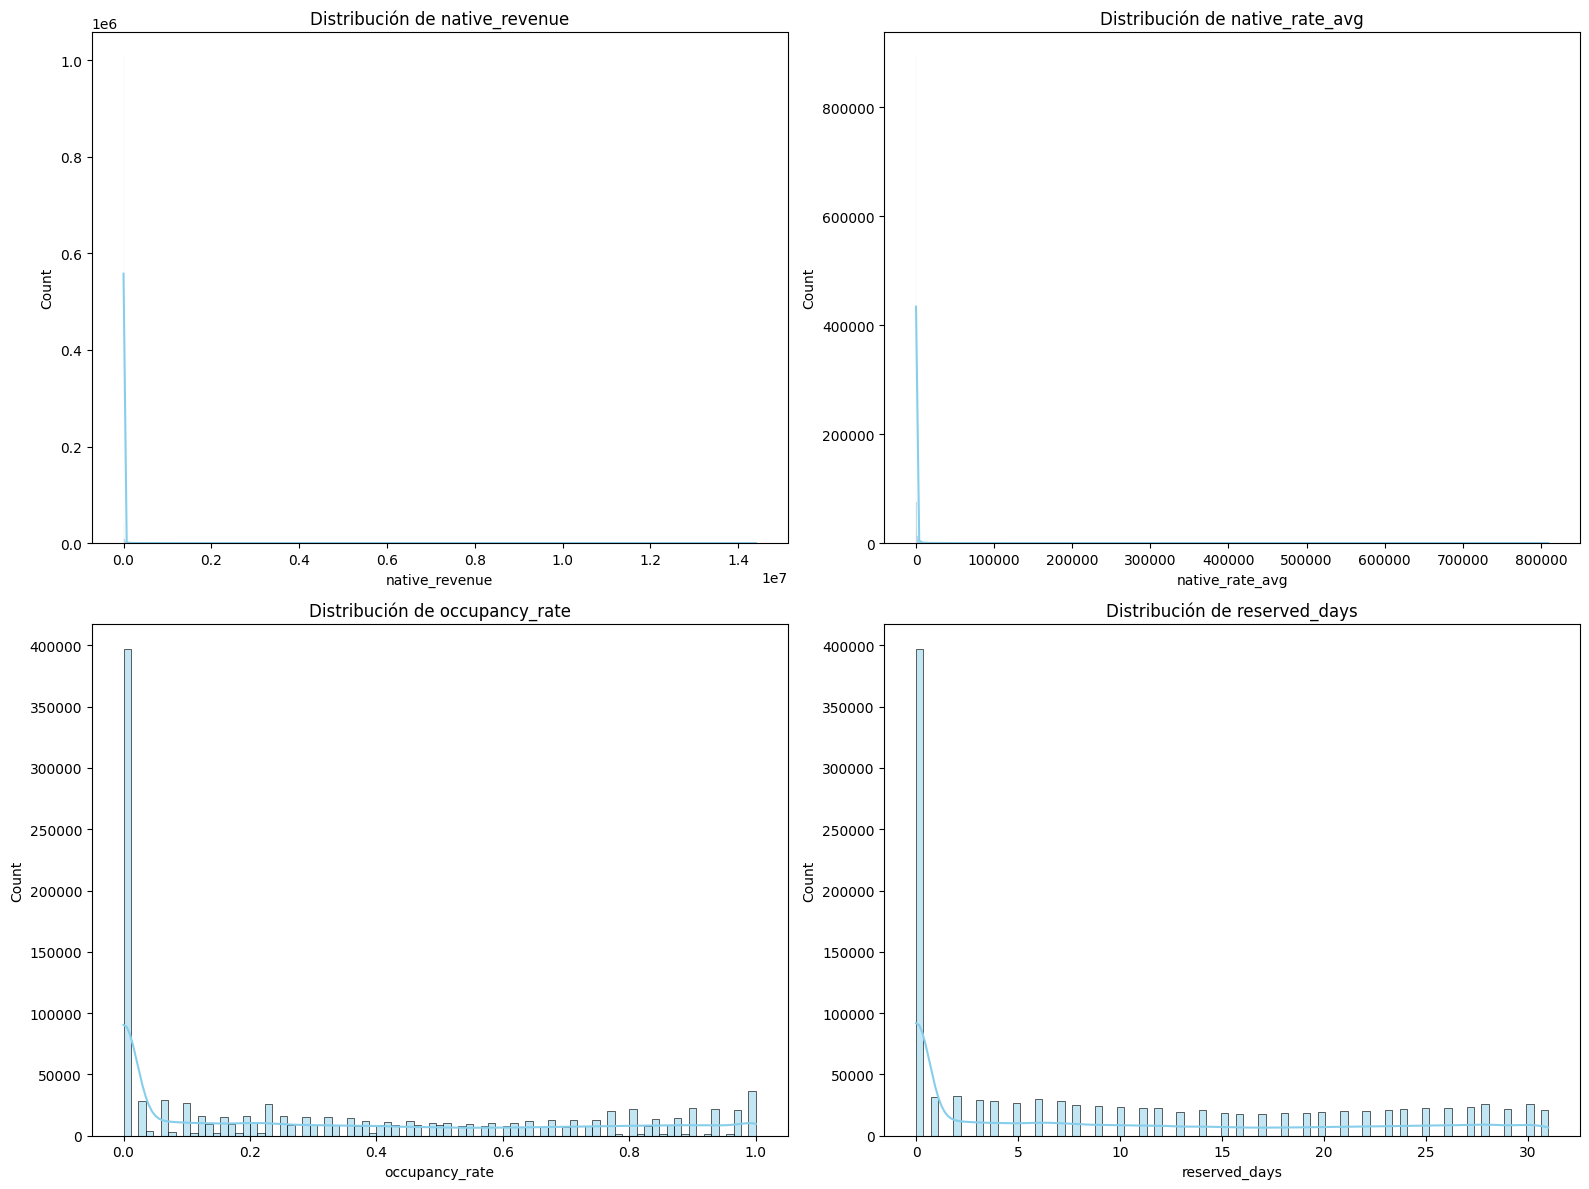

In [39]:
# #### 2. Distributions of key numeric columns

# %%
# Ver cómo se distribuye el lucro y la ocupación
key_numeric_cols = ['native_revenue', 'native_rate_avg', 'occupancy_rate', 'reserved_days']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, col in zip(axes.flatten(), key_numeric_cols):
    sns.histplot(df_fixing[col].dropna(), kde=True, ax=ax, color='skyblue')
    ax.set_title(f'Distribución de {col}')

plt.tight_layout()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_17712\4120190490.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fixing, x="country", y="native_revenue", ax=axes[1], palette="Set2")


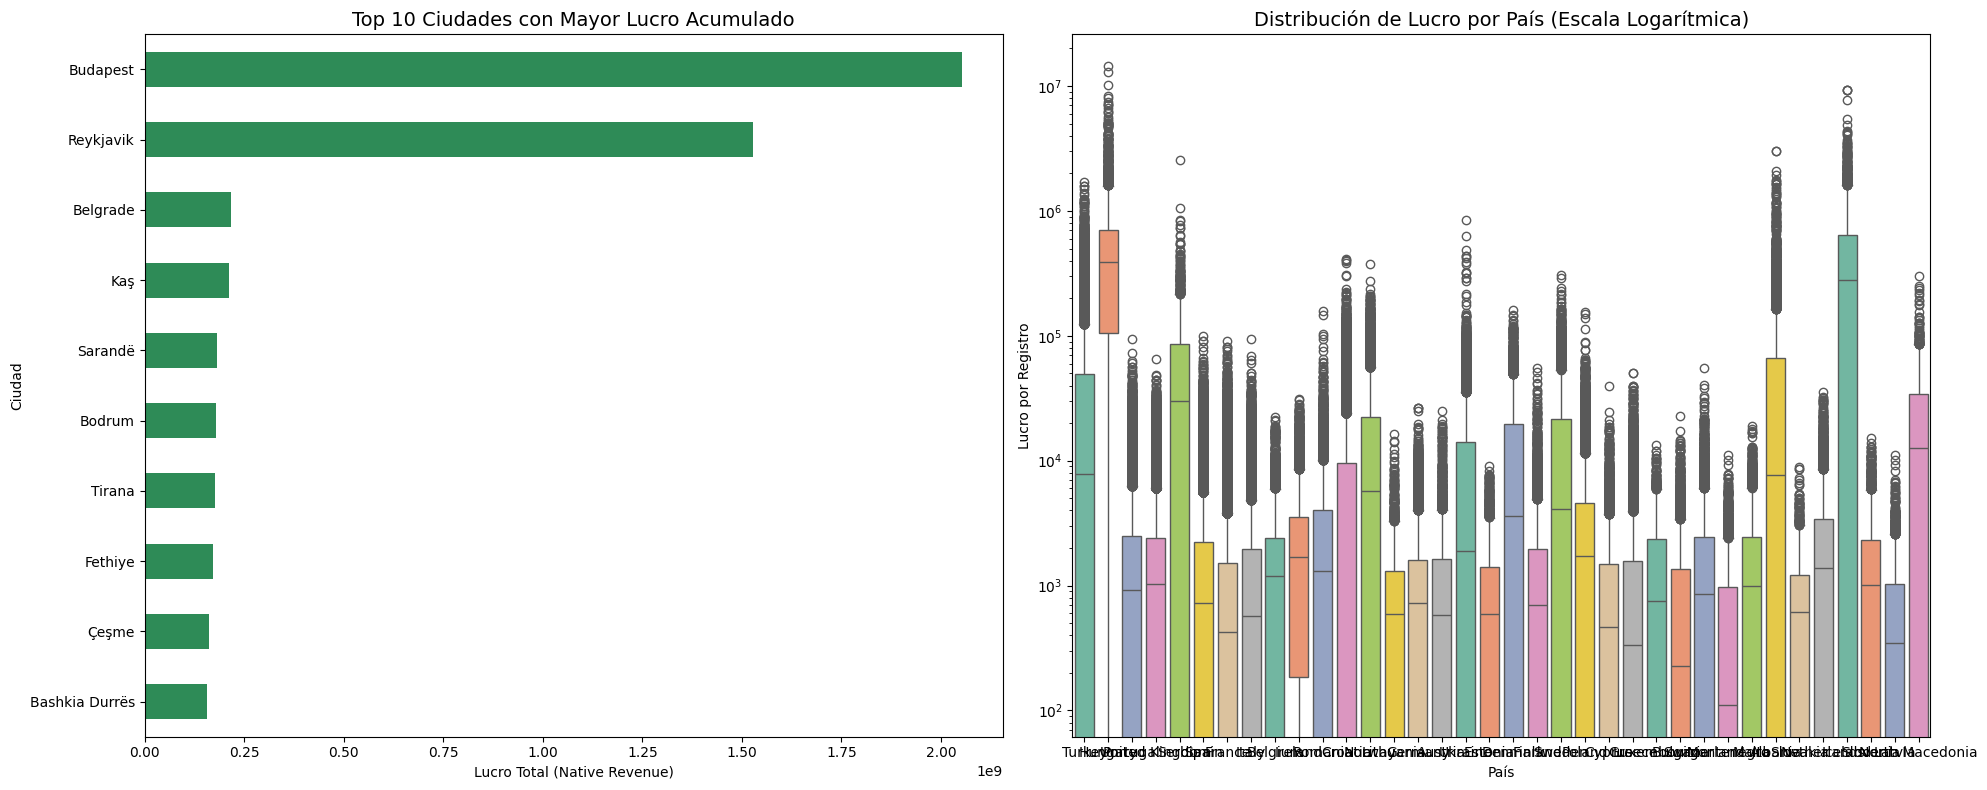

In [40]:
# %% [markdown]
# #### 5. Geographic analysis

# %%
# Configuramos el lienzo para dos gráficas
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# A. Identificar las ciudades estrella (Top 10 por Lucro Total)
# Agrupamos por ciudad y sumamos el native_revenue
top_cities_series = df_fixing.groupby("city")["native_revenue"].sum().sort_values(ascending=False).head(10)

top_cities_series.plot(kind="barh", ax=axes[0], color='seagreen')
axes[0].set_title("Top 10 Ciudades con Mayor Lucro Acumulado", fontsize=14)
axes[0].set_xlabel("Lucro Total (Native Revenue)")
axes[0].set_ylabel("Ciudad")
axes[0].invert_yaxis() # Para que la más rentable salga arriba

# B. Distribución del Lucro por País
# Usamos un Boxplot para ver la dispersión y los outliers (casos de éxito extremo)
sns.boxplot(data=df_fixing, x="country", y="native_revenue", ax=axes[1], palette="Set2")
axes[1].set_yscale("log")  # Escala logarítmica para manejar las diferencias de precios
axes[1].set_title("Distribución de Lucro por País (Escala Logarítmica)", fontsize=14)
axes[1].set_xlabel("País")
axes[1].set_ylabel("Lucro por Registro")

plt.tight_layout()
plt.show()


In [41]:
# %% [markdown]
# ### Final Verification
# #### Checking results after ETL process

# %%
non_null_count_final = df_fixing.notnull().sum().values
nulls_final = df_fixing.isna().sum()
types_final = df_fixing.dtypes.values

info_df_final = pd.DataFrame({
    'Non-Null Count': non_null_count_final,
    'Null Count': nulls_final,
    'Dtypes': types_final
}, index=df_fixing.columns)

print(info_df_final)

                        Non-Null Count  Null Count         Dtypes
listing_id                     1115174           0          int64
date                           1115174           0  datetime64[s]
vacant_days                    1115174           0          int32
reserved_days                  1115174           0          int32
occupancy                      1115174           0        float64
revenue                        1115174           0        float64
rate_avg                       1115174           0        float64
booked_rate_avg                 717806      397368        float64
booking_lead_time_avg           675943      439231        float64
length_of_stay_avg              675943      439231        float64
min_nights_avg                 1089672       25502        float64
native_booked_rate_avg          717806      397368        float64
native_rate_avg                1115174           0        float64
native_revenue                 1115174           0        float64
country   

In [42]:
# %% [markdown]
# ### Adding Business Metric: RevPAR
# #### (Revenue Per Available Room) - La métrica definitiva de lucro

# %%
# RevPAR = Ingresos totales / (Días reservados + Días vacantes)
df_fixing['revpar'] = df_fixing['native_revenue'] / (df_fixing['reserved_days'] + df_fixing['vacant_days'])

# Esto equivale a tu 'amenities_count': una métrica nueva para medir calidad
print(df_fixing[['revpar', 'native_revenue']].describe())

             revpar  native_revenue
count  1.115174e+06    1.115174e+06
mean   2.568930e+02    7.836094e+03
std    2.453233e+03    7.489021e+04
min    0.000000e+00    0.000000e+00
25%    0.000000e+00    0.000000e+00
50%    2.273333e+01    6.900000e+02
75%    7.877419e+01    2.400000e+03
max    4.646027e+05    1.440268e+07


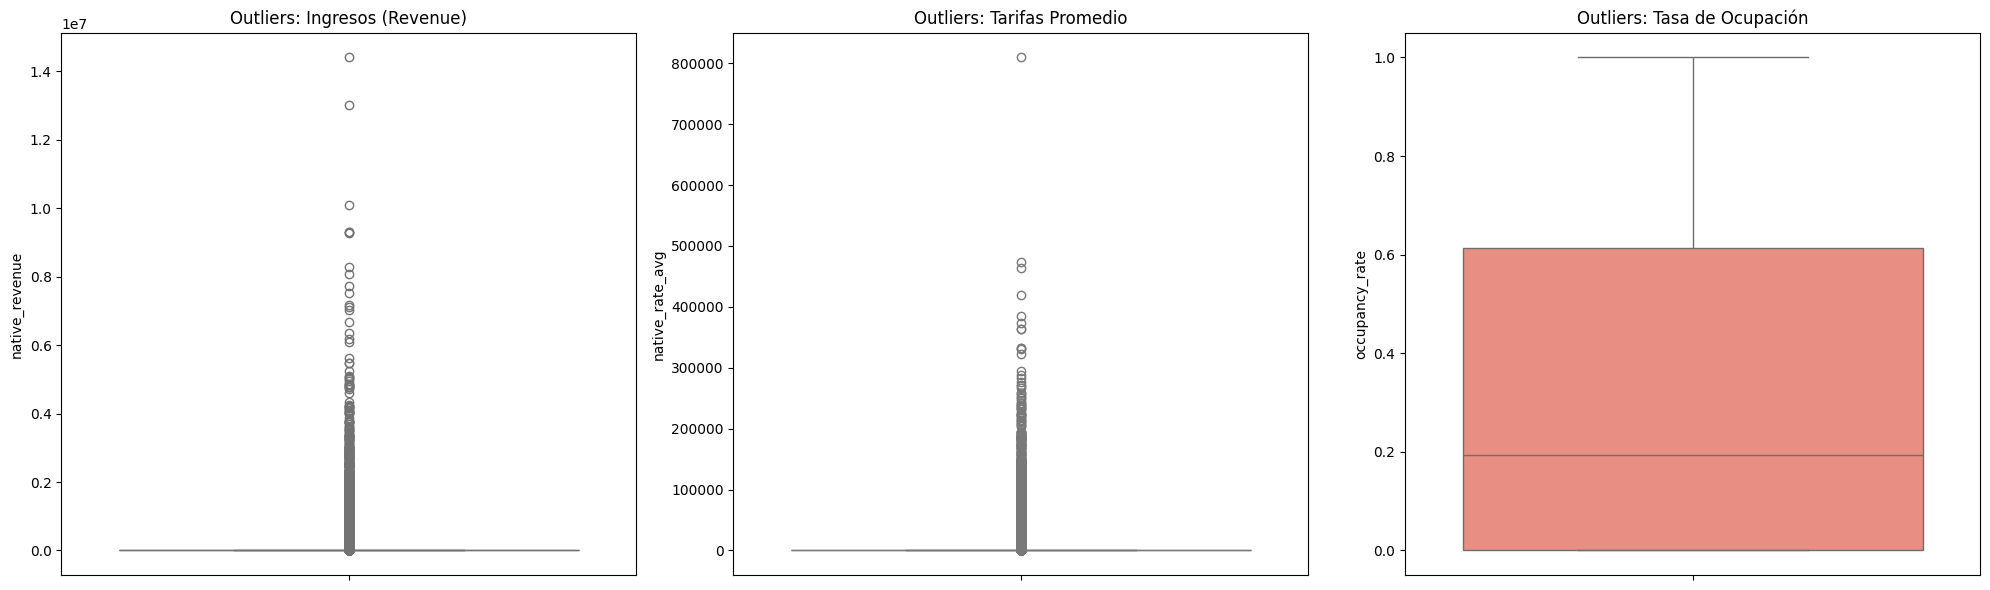

In [43]:
# %% [markdown]
# #### 6. Outliers Analysis
# %%
# Visualizamos qué tan dispersos están los ingresos y las tarifas
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(y=df_fixing['native_revenue'], ax=axes[0], color='lightgreen')
axes[0].set_title('Outliers: Ingresos (Revenue)')

sns.boxplot(y=df_fixing['native_rate_avg'], ax=axes[1], color='lightblue')
axes[1].set_title('Outliers: Tarifas Promedio')

sns.boxplot(y=df_fixing['occupancy_rate'], ax=axes[2], color='salmon')
axes[2].set_title('Outliers: Tasa de Ocupación')

plt.tight_layout()
plt.show()

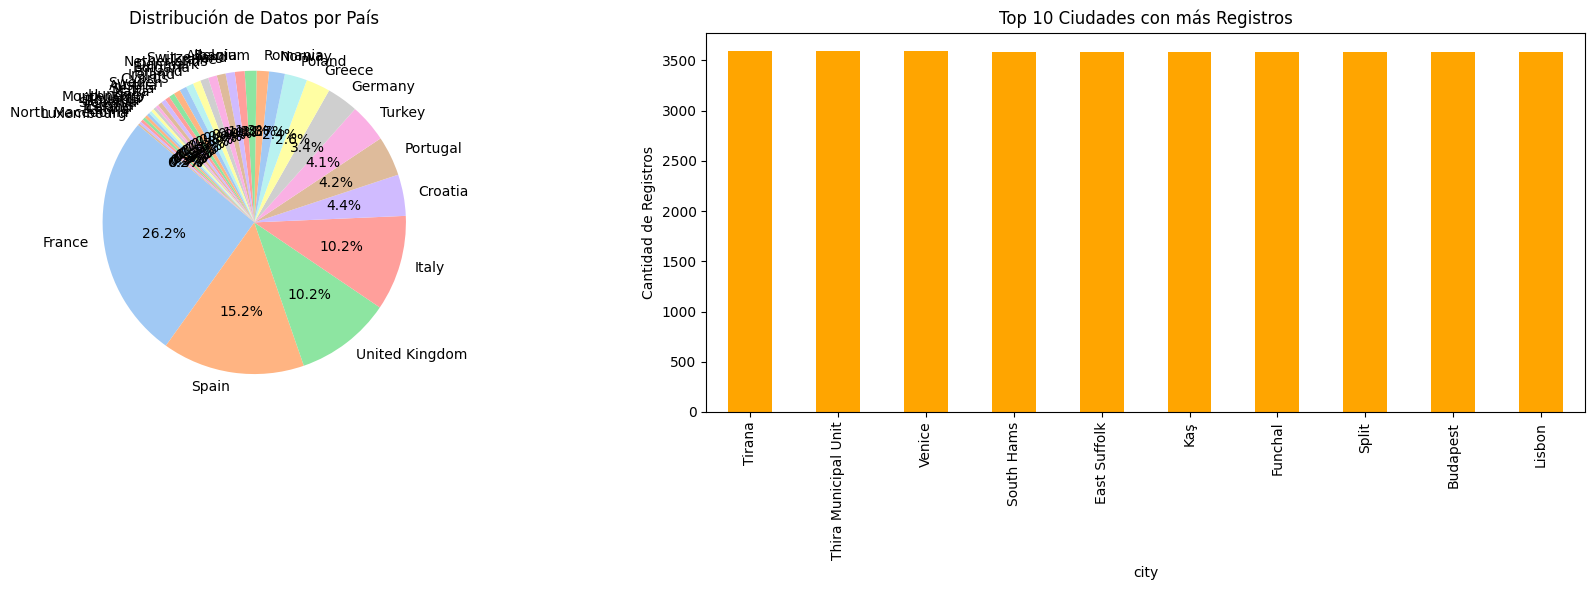

In [44]:
# %% [markdown]
# #### 7. Data Volume by Location
# %%
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Porcentaje de datos por país (Pie Chart como en tu primer script)
df_fixing['country'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0], 
                                         colors=sns.color_palette('pastel'), startangle=140)
axes[0].set_title('Distribución de Datos por País')
axes[0].set_ylabel('')

# Top 10 ciudades con más registros (Bar Chart)
df_fixing['city'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Top 10 Ciudades con más Registros')
axes[1].set_ylabel('Cantidad de Registros')

plt.tight_layout()
plt.show()

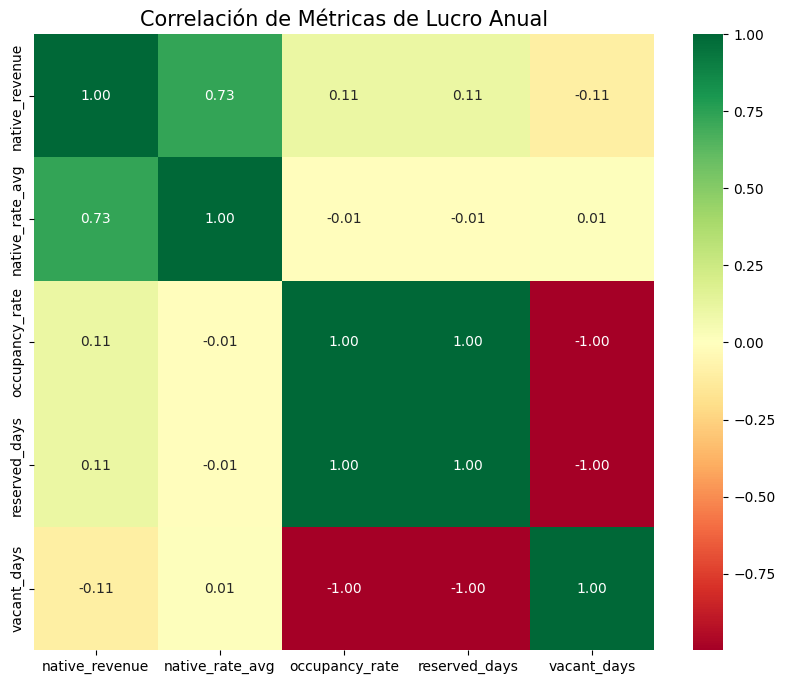

In [45]:
# %% [markdown]
# #### 8. Correlation Heatmap
# %%
# Seleccionamos las columnas numéricas relevantes para el lucro
corr_cols = ['native_revenue', 'native_rate_avg', 'occupancy_rate', 'reserved_days', 'vacant_days']

plt.figure(figsize=(10, 8))
sns.heatmap(df_fixing[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Correlación de Métricas de Lucro Anual", fontsize=15)
plt.show()

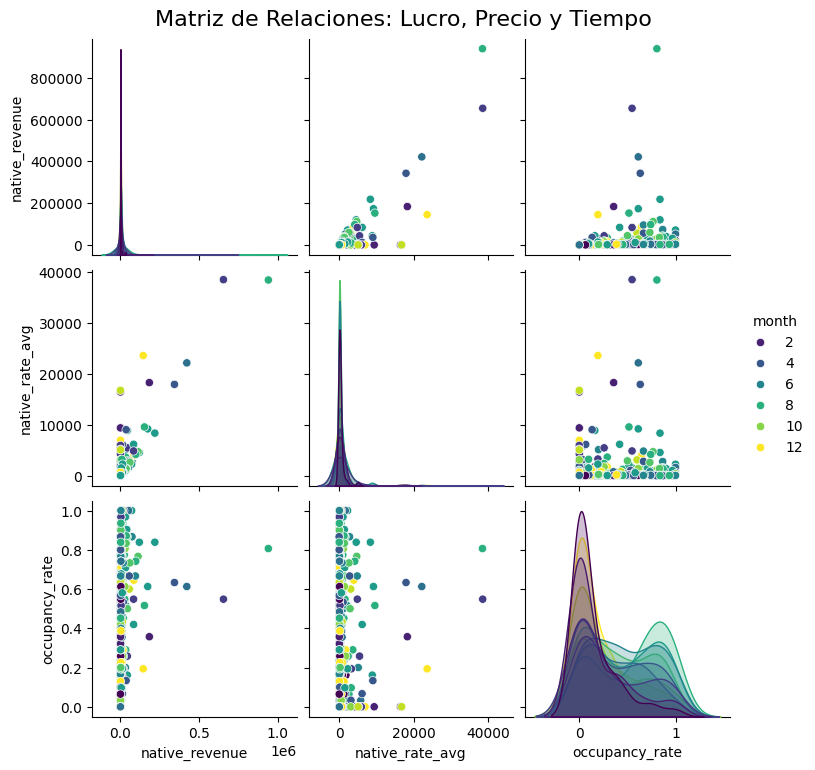

In [46]:
# %% [markdown]
# #### 9. Scatter Matrix (Pairplot)
# %%
# Tomamos una muestra para que el gráfico no sea pesado
df_sample = df_fixing[['native_revenue', 'native_rate_avg', 'occupancy_rate', 'month']].sample(n=min(1000, len(df_fixing)))

# Visualizamos la relación de todo con todo usando el mes como color
sns.pairplot(df_sample, hue='month', palette='viridis', diag_kind='kde')
plt.suptitle("Matriz de Relaciones: Lucro, Precio y Tiempo", y=1.02, fontsize=16)
plt.show()

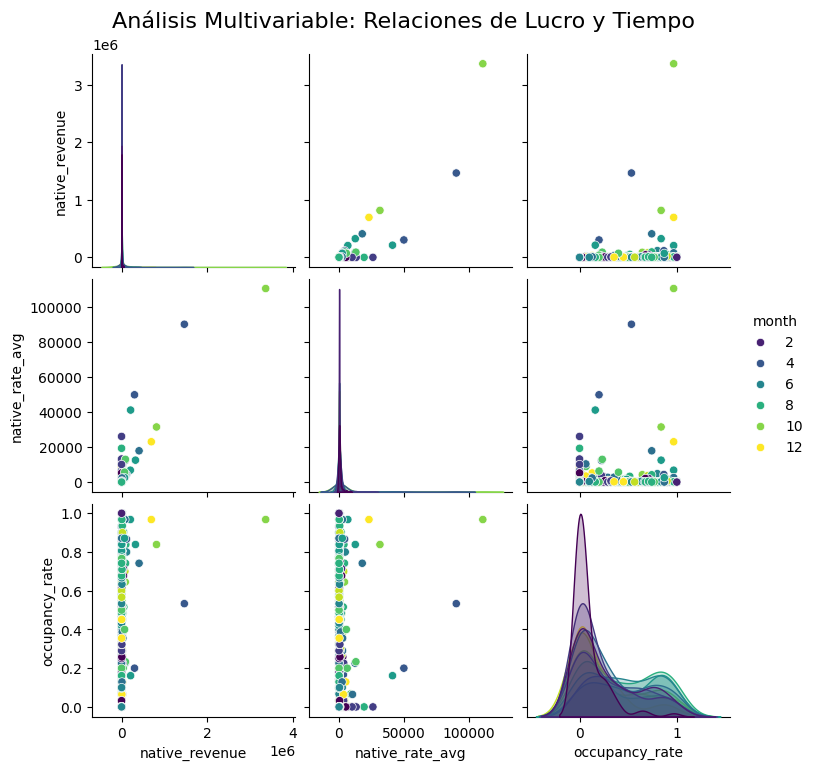

In [47]:
# %% [markdown]
# #### 9. Matriz de Dispersión (Pairplot)
# %%
# 1. Seleccionamos las métricas que realmente nos importan para el lucro
cols_to_plot = ['native_revenue', 'native_rate_avg', 'occupancy_rate', 'month']

# 2. Tomamos una muestra para que no sea lento (si el dataset es gigante)
df_sample = df_fixing[cols_to_plot].sample(n=min(1000, len(df_fixing)))

# 3. Creamos el Pairplot
# 'hue' diferencia los colores por mes para ver el cambio anual
# 'palette' usa colores estilo viridis (de morado a amarillo)
# 'diag_kind' pone curvas suaves en la diagonal
g = sns.pairplot(df_sample, hue='month', palette='viridis', diag_kind='kde', height=2.5)

# Añadimos un título general
g.fig.suptitle("Análisis Multivariable: Relaciones de Lucro y Tiempo", y=1.02, fontsize=16)

plt.show()

In [48]:
# %% [markdown]
# ### Creating new clean .parquet file

# %%
df_fixing.to_parquet(path="../data/clean_past_rates.parquet", engine='pyarrow')
print(f"¡Proceso completado con éxito! Registros finales: {len(df_fixing)}")

¡Proceso completado con éxito! Registros finales: 1115174
